In [1]:
import sys

In [ ]:
!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install torch
!{sys.executable} -m pip install captum
!{sys.executable} -m pip install pygam

In [1]:
import time
import numpy as np
import pandas as pd
import nbimporter

import sklearn.ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
import synthetic_data as syn

synth= syn.synthetic_data_generator(n=500,df=True)

In [17]:
synth= pd.read_csv('datasets/TEXP_synth_data.csv')

# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.297434,1.480258,-1.047823,-1.235156
1,-2.255077,1.190942,-0.573914,-3.008057
2,-3.336307,3.258936,-0.030324,-0.361786
3,0.672172,1.928683,-0.456206,-3.051892
4,-1.106266,3.345063,-3.481175,-1.105859


In [8]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,
                                                                                 train_size=0.80,
                                                                                 random_state=1234)

In [10]:
# the instance to be explained (from train dataset)

target_pos= 9

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

target_inst

,core_1,core_2,noise_1,noise_2
845,0.46423,0.331611,0.465974,0.769212


In [11]:
# data is the training dataset and labels is the labels dataset
# RETURN n, the number of features in data
#        m, the number of unique classes in labels

def get_n_m_sizes(data, labels):
    
    n= data.shape[1]
    
    m= np.asarray(labels.nunique())[0]
    
    return n, m

# Logistic Regression Classifier

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [16]:
# Define the hyperparameters and their respective values
log_param_grid= {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'random_state': [0],
    'max_iter': [100, 1000, 10000],
    'class_weight': [None, 'balanced']
}

# Create an instance of the Logistic Regression classifier
log_model= LogisticRegression()

# Perform grid search with cross-validation
log_grid_search= GridSearchCV(log_model, log_param_grid, cv=5)
log_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
log_best_params= log_grid_search.best_params_
log_best_model = log_grid_search.best_estimator_

# Evaluate the best model
log_accuracy= log_best_model.score(test, labels_test.values.ravel())

print("Best Hyperparameters:", log_best_params)
print("Accuracy with Best Model:", log_accuracy)

Best Hyperparameters: {'C': 10, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l1', 'random_state': 0, 'solver': 'liblinear'}
Accuracy with Best Model: 0.97


In [34]:
import joblib

# Create the logistic regressor
log_model= LogisticRegression(C=10, class_weight='balanced', max_iter=100, penalty='l1', 
                              random_state=0, solver='liblinear')

log_model.fit(train, labels_train.values.ravel())

# Save the trained model
joblib.dump(log_model, 'logistic_regression_model.pkl')

acc_log= sklearn.metrics.accuracy_score(labels_test, log_model.predict(test))
acc_log

0.97

In [41]:
# Create a custom PyTorch model that mimics the behavior of a scikit-learn LogisticRegression model

import torch
import torch.nn as nn

# Define the custom PyTorch model
class LogisticRegressionModel(nn.Module):
    
    def __init__(self, coef, intercept):
        super(LogisticRegressionModel, self).__init__()
        self.coef_ = torch.tensor(coef.T)
        self.intercept_ = torch.tensor(intercept)

    def forward(self, x):
        return torch.sigmoid(torch.matmul(x, self.coef_) + self.intercept_)

# Load the scikit-learn model
model_log= joblib.load('logistic_regression_model.pkl')

# Convert the scikit-learn model to a PyTorch model
log_pytorch_model= LogisticRegressionModel(model_log.coef_, model_log.intercept_)

In [42]:
# Evaluate the PyTorch model
test_tensor= torch.from_numpy(np.asarray(test))
log_preds= log_pytorch_model(test_tensor)
log_preds_binary= (log_preds > 0.5).squeeze().numpy()

accuracy= np.mean(log_preds_binary == labels_test.values.ravel().astype(int))

print("Accuracy:", accuracy)

Accuracy: 0.97


In [43]:
# Apply Integrated Gradients to explain predictions

from captum.attr import IntegratedGradients

# Create an instance of the IntegratedGradients class
ig= IntegratedGradients(log_pytorch_model)

# Define the input data for which you want to explain the prediction
input_data= torch.from_numpy(np.asarray(target_inst))

# Compute the attributions using Integrated Gradients
attributions= ig.attribute(input_data)

np.asarray(attributions)

array([[-0.21948943,  0.1455993 ,  0.00635973, -0.00067306]])

In [44]:
# Apply Integrated Gradients to explain predictions

from captum.attr import InputXGradient

# Create an instance of the InputXGradient class
input_x_gradient= InputXGradient(log_pytorch_model)

# Compute the importance scores using Input × Gradient
attributions= input_x_gradient.attribute(input_data)

# Get feature importance scores
np.asarray(attributions.tolist())

/home/evortigosa/anaconda3/lib/python3.8/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(


array([[-2.67780467e-03,  1.77633377e-03,  7.75897211e-05,
        -8.21147375e-06]])

# K-NN Classifier

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Define the hyperparameters and their respective values
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'metric': ['euclidean', 'manhattan']
}

# Create an instance of the KNN classifier
knn_model= KNeighborsClassifier()

# Perform grid search with cross-validation
knn_grid_search= GridSearchCV(knn_model, knn_param_grid, cv=5)
knn_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
knn_best_params= knn_grid_search.best_params_
knn_best_model = knn_grid_search.best_estimator_

# Evaluate the best model
knn_accuracy= knn_best_model.score(train, labels_train.values.ravel())

print("Best Hyperparameters:", knn_best_params)
print("Accuracy with Best Model:", knn_accuracy)

Best Hyperparameters: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Accuracy with Best Model: 1.0


In [183]:
# Create the KNN classifier 
knn_model= KNeighborsClassifier(algorithm='auto', metric='euclidean', n_neighbors=3, weights='distance')

knn_model.fit(np.asarray(train), labels_train.values.ravel())

# Save the trained model
joblib.dump(knn_model, 'knn_model.pkl')

acc_knn= sklearn.metrics.accuracy_score(labels_test, knn_model.predict(np.asarray(test)))
acc_knn

0.935

In [239]:
# Create a custom PyTorch model that mimics the behavior of a scikit-learn KNeighborsClassifier model

# Define the custom PyTorch model
class KNeighborsClassifierModel(nn.Module):
    def __init__(self, model):
        super(KNeighborsClassifierModel, self).__init__()
        self.model= model

    def forward(self, x):
        _, indices= self.model.kneighbors(x)
        return torch.from_numpy(self.model.classes_).unsqueeze(0), torch.from_numpy(self.model.predict_proba(x))
    
# Load the scikit-learn model
model_knn= joblib.load('knn_model.pkl')

# Convert the scikit-learn model to a PyTorch model
knn_pytorch_model= KNeighborsClassifierModel(model_knn)

In [220]:
# Evaluate the PyTorch model
knn_classes, knn_preds= knn_pytorch_model(test_tensor)

accuracy= np.mean(np.asarray(knn_preds) == labels_test.values.ravel().astype(int))

print("Accuracy:", accuracy)

Accuracy: 0.935


In [241]:
# The scikit-learn KNeighborsClassifier model is not directly compatible with the Integrated Gradients 
# and Gradient x Input methods in Captum. Integrated Gradients requires a model to be differentiable, 
# meaning its parameters can be updated through gradient-based optimization. However, K-nearest neighbors 
#(KNN) models, including KNeighborsClassifier, do not have differentiable parameters.

# Integrated Gradients and Gradient x Input are typically applied to models based on differentiable 
# functions, such as neural networks, where gradients can be computed. KNN models, on the other hand, 
# are based on non-parametric distance metrics and do not have a clear notion of gradients.

# SVM Classifier

In [19]:
from sklearn.svm import SVC

# Define the hyperparameters and their respective values
svm_param_grid= {
    'C': [0.01, 0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': [0.01, 0.1, 1, 2],
    'class_weight': [None, 'balanced']
}

# Create an instance of the SVM classifier
svm_model= SVC()

# Perform grid search with cross-validation
svm_grid_search= GridSearchCV(svm_model, svm_param_grid, cv=5)
svm_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
svm_best_params= svm_grid_search.best_params_
svm_best_model = svm_grid_search.best_estimator_

# Evaluate the best model
svm_accuracy= svm_best_model.score(train, labels_train.values.ravel())

print("Best Hyperparameters:", svm_best_params)
print("Accuracy with Best Model:", svm_accuracy)

Best Hyperparameters: {'C': 10, 'class_weight': None, 'gamma': 2, 'kernel': 'rbf'}
Accuracy with Best Model: 0.97


In [73]:
# Create the SVM classifier 
svm_model= SVC(C=10, class_weight=None, gamma=2, kernel='rbf')

svm_model.fit(train, labels_train.values.ravel())

acc_svm= sklearn.metrics.accuracy_score(labels_test, svm_model.predict(test))
acc_svm

0.975

In [ ]:
# The scikit-learn SVC (Support Vector Classifier) model is not directly compatible with the Integrated 
# Gradients method in Captum. Integrated Gradients requires a model to be differentiable, meaning its 
# parameters can be updated through gradient-based optimization. However, the SVC model in scikit-learn, 
# which is based on Support Vector Machines, does not have differentiable parameters.

# Integrated Gradients is typically applied to models based on differentiable functions, such as neural 
# networks, where gradients can be computed. Support Vector Machines, including the SVC model, involve 
# solving an optimization problem to find the hyperplane that maximally separates the data points. This 
# optimization process does not provide direct access to gradients for attribution computations.

# Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Define the hyperparameters and their respective values
rfc_param_grid= {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 6, 7, 9],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'random_state': [0],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

# Create an instance of the Random Forest Classifier
rfc_model= RandomForestClassifier()

# Perform grid search with cross-validation
rfc_grid_search= GridSearchCV(rfc_model, rfc_param_grid, cv=5)
rfc_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
rfc_best_params= rfc_grid_search.best_params_
rfc_best_model = rfc_grid_search.best_estimator_

# Evaluate the best model
rfc_accuracy= rfc_best_model.score(train, labels_train.values.ravel())

print("Best Hyperparameters:", rfc_best_params)
print("Accuracy with Best Model:", rfc_accuracy)

Best Hyperparameters: {'class_weight': None, 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500, 'random_state': 0}
Accuracy with Best Model: 0.98625


In [250]:
# Create the RF classifier 
rfc_model= RandomForestClassifier(max_depth=7, 
                                  min_samples_leaf=2, min_samples_split=2, n_estimators=500, 
                                  random_state=0)

rfc_model.fit(np.asarray(train), labels_train.values.ravel())

# Save the trained model
joblib.dump(rfc_model, 'random_forest_model.pkl')

acc_rfc= sklearn.metrics.accuracy_score(labels_test, rfc_model.predict(np.asarray(test)))
acc_rfc

0.96

In [253]:
# Define the custom PyTorch model
class RandomForestClassifierModel(nn.Module):
    def __init__(self, model):
        super(RandomForestClassifierModel, self).__init__()
        self.model= model

    def forward(self, x):
        # Perform inference using the RandomForestClassifier model
        probabilities= self.model.predict_proba(x)
        #probabilities= self.model.predict(x)
        return torch.from_numpy(probabilities)

# Load the scikit-learn model
model_rf= joblib.load('random_forest_model.pkl')

# Convert the scikit-learn model to a PyTorch model
rfc_pytorch_model= RandomForestClassifierModel(model_rf)

In [252]:
# Evaluate the PyTorch model
test_tensor= torch.from_numpy(np.asarray(test))
rfc_preds= rfc_pytorch_model(test_tensor)

accuracy= np.mean(np.asarray(rfc_preds) == labels_test.values.ravel().astype(int))

print("Accuracy:", accuracy)

Accuracy: 0.96


In [264]:
# The scikit-learn RandomForestClassifier model is not directly compatible with the Integrated Gradients 
# method in Captum. Integrated Gradients requires a model to be differentiable, meaning its parameters 
# can be updated through gradient-based optimization. However, the RandomForestClassifier model in 
# scikit-learn is an ensemble model that combines multiple decision trees, and individual decision trees 
# within the ensemble are not differentiable.

# Integrated Gradients is typically applied to models based on differentiable functions, such as neural 
# networks, where gradients can be computed. Random Forest models, on the other hand, are based on an 
# ensemble of decision trees, and each decision tree is trained independently using different splitting rules.

# If you want to use the Integrated Gradients method with a RandomForestClassifier model, you would need to 
# convert the RandomForestClassifier into a differentiable model representation. One possible approach is to 
# create a surrogate model, such as a neural network, that approximates the behavior of the 
# RandomForestClassifier. This approximation would allow you to compute gradients and apply the 
# Integrated Gradients method.

# Converting a scikit-learn RandomForestClassifier model into a differentiable model representation for 
# use with the Integrated Gradients method requires approximating the behavior of the random forest. 
# One approach is to create a surrogate model, such as a neural network, that approximates the 
# predictions of the random forest.

# XGBoost RF Classifier

In [21]:
import xgboost as xgb

# Define the hyperparameters and their respective values
xgb_param_grid= {
    'max_depth': [3, 5, 6, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200, 500],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0.1, 0.2, 0.5, 1],
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss']
}

# Create an instance of the XGBoost classifier
xgb_model= xgb.XGBRFClassifier()

#eval_set= [(train, labels_train), (test, labels_test)]

#xgb_model.fit(train, labels_train, eval_set=eval_set, verbose=False)

#sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

# Perform grid search with cross-validation
xgb_grid_search= GridSearchCV(xgb_model, xgb_param_grid, cv=5)
xgb_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
xgb_best_params= xgb_grid_search.best_params_
xgb_best_model = xgb_grid_search.best_estimator_

# Evaluate the best model
xgb_accuracy= xgb_best_model.score(train, labels_train.values.ravel())

print("Best Hyperparameters:", xgb_best_params)
print("Accuracy with Best Model:", xgb_accuracy)

Best Hyperparameters: {'colsample_bytree': 0.8, 'eval_metric': 'logloss', 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 500, 'objective': 'binary:logistic', 'subsample': 0.9}
Accuracy with Best Model: 0.9825


In [261]:
import pickle

# Create the XGBoost classifier 
xgb_model= xgb.XGBRFClassifier(learning_rate= 0.01, n_estimators= 500, max_depth= 6,
                               gamma= 0.1, subsample= 0.9,
                               objective= 'binary:logistic',
                               eval_metric='logloss')

xgb_model.fit(train, labels_train.values.ravel())

# Save the trained model
with open('xgbrf_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

acc_xgb= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))
acc_xgb

0.96

In [262]:
# Define the custom PyTorch model
class XGBRFClassifierModel(nn.Module):
    def __init__(self, model):
        super(XGBRFClassifierModel, self).__init__()
        self.model= model

    def forward(self, x):
        logits= self.model.predict(xgb.DMatrix(x))
        probabilities= torch.softmax(torch.from_numpy(logits), dim=1)
        return probabilities

# Load the XGBoost model
with open('xgbrf_model.pkl', 'rb') as f:
    model_xgb= pickle.load(f)

# Convert the XGBoost model to a PyTorch model
xgb_pytorch_model= XGBRFClassifierModel(model_xgb)

# Neural Networks -- 1, 2, and 3 hyden layers

In [35]:
from sklearn.neural_network import MLPClassifier

In [25]:
# Define the hyperparameters and their respective values
nn1_param_grid= {
    'hidden_layer_sizes': [(64,), (128,), (256,)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'random_state': [0],
    'max_iter': [500, 1000],
    'alpha': [0.001, 0.01]
}

# Create an instance of the MLPClassifier
nn1_model= MLPClassifier()

# Perform grid search with cross-validation
nn1_grid_search= GridSearchCV(nn1_model, nn1_param_grid, cv=5, scoring='accuracy')
nn1_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
nn1_best_params= nn1_grid_search.best_params_
nn1_best_model = nn1_grid_search.best_estimator_

# Evaluate the best model
nn1_accuracy= nn1_best_model.score(train, labels_train.values.ravel())

print("Best Hyperparameters:", nn1_best_params)
print("Accuracy with Best Model:", nn1_accuracy)

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacon

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacon

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anac

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaco

...

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/ana

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/ana

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacon

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacon

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (256,), 'learning_rate_init': 0.001, 'max_iter': 500, 'random_state': 0, 'solver': 'adam'}
Accuracy with Best Model: 0.9675


In [36]:
# Create the 1-hyden layer Neural Net classifier 
nn1_model= MLPClassifier(activation='relu', alpha=0.01, hidden_layer_sizes=(256,), 
                         learning_rate_init=0.001, max_iter=500, random_state=0, solver='adam')

nn1_model.fit(train, labels_train.values.ravel())

acc_nn1= sklearn.metrics.accuracy_score(labels_test, nn1_model.predict(test))
acc_nn1

0.975

In [26]:
# Define the hyperparameters and their respective values
nn2_param_grid= {
    'hidden_layer_sizes': [(64,64), (128,128), (256,256), (512,512)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'random_state': [0],
    'max_iter': [500, 1000],
    'alpha': [0.0001, 0.001, 0.01]
}

# Create an instance of the MLPClassifier
nn2_model= MLPClassifier()

# Perform grid search with cross-validation
nn2_grid_search= GridSearchCV(nn2_model, nn2_param_grid, cv=5, scoring='accuracy')
nn2_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
nn2_best_params= nn2_grid_search.best_params_
nn2_best_model = nn2_grid_search.best_estimator_

# Evaluate the best model
nn2_accuracy= nn2_best_model.score(train, labels_train.values.ravel())

print("Best Hyperparameters:", nn2_best_params)
print("Accuracy with Best Model:", nn2_accuracy)

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/ana

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/ana

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64, 64), 'learning_rate_init': 0.001, 'max_iter': 500, 'random_state': 0, 'solver': 'adam'}
Accuracy with Best Model: 0.96875


In [37]:
# Create the 2-hyden layers Neural Net classifier 
nn2_model= MLPClassifier(activation='relu', alpha=0.001, hidden_layer_sizes=(64, 64), 
                         learning_rate_init=0.001, max_iter=500, random_state=0, solver='adam')

nn2_model.fit(train, labels_train.values.ravel())

acc_nn2= sklearn.metrics.accuracy_score(labels_test, nn2_model.predict(test))
acc_nn2

0.97

In [27]:
# Define the hyperparameters and their respective values
nn3_param_grid= {
    'hidden_layer_sizes': [(64,64,64), (128,128,128), (256,256,256), (512,512,512)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'random_state': [0],
    'max_iter': [500, 1000],
    'alpha': [0.0001, 0.001, 0.01]
}

# Create an instance of the MLPClassifier
nn3_model= MLPClassifier()

# Perform grid search with cross-validation
nn3_grid_search= GridSearchCV(nn3_model, nn3_param_grid, cv=5, scoring='accuracy')
nn3_grid_search.fit(train, labels_train.values.ravel())

# Retrieve the best hyperparameters and model
nn3_best_params= nn3_grid_search.best_params_
nn3_best_model = nn3_grid_search.best_estimator_

# Evaluate the best model
nn3_accuracy= nn3_best_model.score(train, labels_train.values.ravel())

print("Best Hyperparameters:", nn3_best_params)
print("Accuracy with Best Model:", nn3_accuracy)

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/evortigosa/anacond

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 64, 64), 'learning_rate_init': 0.01, 'max_iter': 500, 'random_state': 0, 'solver': 'sgd'}
Accuracy with Best Model: 0.9675


In [185]:
# Create the 3-hyden layers Neural Net classifier 
nn3_model= MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(64, 64, 64), 
                         learning_rate_init=0.01, max_iter=500, random_state=0, solver='sgd')

nn3_model.fit(np.asarray(train), labels_train.values.ravel())

# Save the trained model
joblib.dump(nn3_model, 'mlp_model.pkl')

acc_nn3= sklearn.metrics.accuracy_score(np.asarray(labels_test), nn3_model.predict(np.asarray(test)))
acc_nn3

0.975

In [256]:
# Define the PyTorch Neural Network model to conversion
class MLPClassifierModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLPClassifierModel, self).__init__()
        
        self.layers= nn.ModuleList([nn.Linear(input_size, hidden_sizes[0])])
        self.activations= [nn.ReLU()]
        
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.activations.append(nn.ReLU())
        
        self.output_layer= nn.Linear(hidden_sizes[-1], output_size)

        
    def forward(self, x):
        for layer, activation in zip(self.layers, self.activations):
            x= activation(layer(x))
        
        x= self.output_layer(x)
        
        return x

In [475]:
# convert a scikit-learn NN model to a PyTorch NN model

# skl_nn_model is the scikit-learn Neural Net model
# input_size is the number of input features

# RETURN a PyTorch Neural Net model used to binary classifications

def sklearn_to_pytorch_NN(skl_nn_model, input_size):

    # Convert the scikit-learn model to a PyTorch model
    input_size= input_size
    hidden_sizes= skl_nn_model.hidden_layer_sizes
    output_size= 1  # binary classification -- one output neuron for the binary prediction

    nn_pytorch_model= MLPClassifierModel(input_size, hidden_sizes, output_size)

    # Transfer the weights from the scikit-learn model to the PyTorch model
    for i, layer in enumerate(nn_pytorch_model.layers):
        layer.weight.data= torch.tensor(skl_nn_model.coefs_[i].T, dtype=torch.float32)
        layer.bias.data= torch.tensor(skl_nn_model.intercepts_[i], dtype=torch.float32)

    nn_pytorch_model.output_layer.weight.data= torch.tensor(skl_nn_model.coefs_[-1].T, dtype=torch.float32)
    nn_pytorch_model.output_layer.bias.data= torch.tensor(skl_nn_model.intercepts_[-1], dtype=torch.float32)
    
    # Set the register_full_backward_hook for each linear layer
    def backward_hook(module, grad_input, grad_output, grads:bool=False):
        if (grads==True):
            print("Grad Input:", grad_input)
            print("Grad Output:", grad_output)

    for layer in nn_pytorch_model.layers:
        if isinstance(layer, nn.Linear):
            layer.register_full_backward_hook(backward_hook)
    
    return nn_pytorch_model

In [ ]:
# Load the scikit-learn model
model= joblib.load('mlp_model.pkl')

# Convert the scikit-learn model to a PyTorch model
input_size= train.shape[1]
hidden_sizes= model.hidden_layer_sizes
output_size= 1  # binary classification -- one output neuron for the binary prediction

nn3_pytorch_model= MLPClassifierModel(input_size, hidden_sizes, output_size)

# Transfer the weights from the scikit-learn model to the PyTorch model
for i, layer in enumerate(nn3_pytorch_model.layers):
    layer.weight.data= torch.tensor(model.coefs_[i].T, dtype=torch.float32)
    layer.bias.data= torch.tensor(model.intercepts_[i], dtype=torch.float32)

nn3_pytorch_model.output_layer.weight.data= torch.tensor(model.coefs_[-1].T, dtype=torch.float32)
nn3_pytorch_model.output_layer.bias.data= torch.tensor(model.intercepts_[-1], dtype=torch.float32)

In [225]:
# convert log odds values to predicted classes in a binary classification problem

def log_odds_to_binary_class(lodds):
    
    p= np.exp(lodds) / (1 + np.exp(lodds))
    
    return 0 if (p< 0.5) else 1

In [476]:
# Evaluate the PyTorch model
nn3_pytorch_model= sklearn_to_pytorch_NN(nn3_model, 4)

test_tensor= torch.tensor(np.asarray(test), dtype=torch.float32)
preds= nn3_pytorch_model(test_tensor)

preds= (preds.detach().numpy()).reshape(labels_test.values.ravel().shape)

for i in range(preds.shape[0]):
    preds[i]= log_odds_to_binary_class(preds[i])

accuracy= np.mean(preds == labels_test.values.ravel().astype(int))

print("Accuracy:", accuracy)

Accuracy: 0.975


In [255]:
print('NNs agreement:', sklearn.metrics.accuracy_score(preds, nn3_model.predict(np.asarray(test))))

NNs agreement: 1.0


In [452]:
from captum.attr import IntegratedGradients

# Create an instance of the IntegratedGradients class
ig= IntegratedGradients(nn3_pytorch_model)

# Select a data instance for explanation
input_data= torch.tensor(np.asarray(target_inst), dtype=torch.float32)
input_data.requires_grad= True

# Compute the attributions using Integrated Gradients
attributions= ig.attribute(input_data)

(attributions.squeeze()).detach()

tensor([-12.2714,   8.5119,   0.1579,  -0.4624], dtype=torch.float64)

In [477]:
from captum.attr import InputXGradient

# Create an instance of the InputXGradient class
input_x_gradient= InputXGradient(nn3_pytorch_model)

# Compute the importance scores using Input × Gradient
attributions= input_x_gradient.attribute(input_data.unsqueeze(0))

# Get feature importance scores
print(attributions.squeeze().detach())

tensor([-11.4172,   7.7901,   0.2206,  -0.4884])


In [446]:
from captum.attr import DeepLift

# Create an instance of the DeepLift class
dl= DeepLift(nn3_pytorch_model)

# Compute the attributions using DeepLift
attributions= dl.attribute(input_data.unsqueeze(0))

(attributions.squeeze())

tensor([-11.4172,   7.7901,   0.2206,  -0.4884], grad_fn=<SqueezeBackward0>)

In [439]:
from captum.attr import LRP

# Create an instance of the LayerLRP class
lrp= LRP(nn3_pytorch_model)

# Compute the attributions using LRP
attributions= lrp.attribute(input_data.unsqueeze(0))

(attributions.squeeze())

tensor([-11.4172,   7.7901,   0.2206,  -0.4884], grad_fn=<SqueezeBackward0>)

In [344]:
def ris_measure(x_data, x_pert, exp_data, exp_pert, p_norm=2, eps=0.001):
    
    x_dif_norm= lp_norm_dif(x_data, x_pert, p_norm=p_norm, eps=eps, norm=True)
    #x_dif_norm= np.clip(x_dif_norm, eps, None)
    x_dif_norm= clip_small_values(x_dif_norm, eps)
    
    print('x_dif_norm', x_dif_norm, '\n')
    
    exp_dif_norm= lp_norm_dif(exp_data, exp_pert, p_norm=p_norm, eps=eps, norm=True)
    
    print('exp_dif_norm', exp_dif_norm, '\n')
    
    stability_measure= np.divide(exp_dif_norm, x_dif_norm, where=x_dif_norm!=0)
    
    """
    print('x_data', x_data)
    print('x_pert', x_pert)
    print('x_dif_norm', x_dif_norm)
    print('exp_ dif_norm', exp_dif_norm)
    print('stab_measure', stability_measure)
    """
    
    return stability_measure

In [329]:
x = np.asarray([0.1395, 0.7157, 0.3522, 0.6721])
xp= np.asarray([0.1396, 0.7226, 0.3581, 0.6695])

In [330]:
e= np.asarray([ 1.5610e-05,  5.1622e-02,  7.8500e-05, -2.3351e-18])
ep= np.asarray([ 1.5617e-05,  5.2124e-02,  4.9251e-04, -6.2826e-18])

In [345]:
# lp_norm_dif

ris_measure(x, xp, e, ep, p_norm=2, eps=1e-6)

dif before div [-1.0e-04 -6.9e-03 -5.9e-03  2.6e-03]
v1 afterr clip [0.1395 0.7157 0.3522 0.6721]
dif afterr div [-0.00071685 -0.00964091 -0.01675185  0.00386847]
x_dif_norm 0.01972436151511782 

dif before div [-7.0000e-09 -5.0200e-04 -4.1401e-04  3.9475e-18]
v1 afterr clip [ 1.5610e-05  5.1622e-02  7.8500e-05 -1.0000e-06]
dif afterr div [-4.48430493e-04 -9.72453605e-03 -5.27401274e+00 -3.94750000e-12]
exp_dif_norm 5.274021723246913 



267.3861822703167

In [339]:
e - ep

array([-7.0000e-09, -5.0200e-04, -4.1401e-04,  3.9475e-18])

In [336]:
def lp_norm_dif(v1, v2, p_norm=2, eps=1e-6, norm:bool=True):
    
    # arrays can be flattened, so long as ordering is preserved
    v1_flat= np.asarray(v1).flatten()
    v2_flat= np.asarray(v2).flatten()
    
    dif_flat= (v1_flat - v2_flat)
    
    if (norm==True): print('dif before div', dif_flat)
    
    if (norm==True):
        #v1_flat= np.clip(v1_flat, eps, None)
        v1_flat= clip_small_values(v1_flat, eps)
        
        if (norm==True): print('v1 afterr clip', v1_flat)
        
        dif_flat= np.divide(dif_flat, v1_flat, out=np.zeros_like(v1_flat), where=v1_flat!=0)
        
        #v2_flat= clip_small_values(v2_flat, eps) 
        #dif_flat= 1 - np.divide(v2_flat, v1_flat, out=np.zeros_like(v1_flat), where=v1_flat!=0)
        
    if (norm==True): print('dif afterr div', dif_flat)

    return np.linalg.norm(dif_flat, ord=p_norm)

In [22]:
def lp_norm_dif_v0(v1, v2, p_norm=2, eps=1e-6, norm:bool=True):
    
    # arrays can be flattened, so long as ordering is preserved
    flat_dif= np.asarray(v1).flatten() - np.asarray(v2).flatten()
    
    #if (norm==True): print('dif before div', flat_dif)
    
    if (norm==True):
        v1_aux= np.asarray(v1).flatten()
        v1_aux= np.clip(v1_aux, eps, None)
        
        #if (norm==True): print('dif after clip', v1_aux)
                    
        flat_dif= np.divide(flat_dif, v1_aux, where=v1_aux!= 0)
        
    #if (norm==True): print('dif afterr div', flat_dif)

    return np.linalg.norm(flat_dif, ord=p_norm)

In [12]:
lp_norm_dif(a, b, p_norm=2, eps=1e-6, norm=True)

dif before div [ 6.01780e-05  3.99814e-03 -2.60157e-18 -2.60500e-18]
dif after clip [3.0089e-05 4.1239e-03 1.0000e-06 1.0000e-06]
dif afterr div [ 2.00000000e+00  9.69504595e-01 -2.60157000e-12 -2.60500000e-12]


2.2225973904523526

In [303]:
# clip values near to zero in v replacing by eps

# v numpy.ndarray with (n,) shape
# eps is a small number of tolerance limiting what is a small value

# RETURN v clipped

def clip_small_values(v, eps=1e-6):
    
    v_aux= v.copy()
    
    if (type(v_aux)== np.ndarray):
        elements= v_aux.shape[0]

        for i in range(elements):

            if (v_aux[i]< 0 and np.abs(v_aux[i])< eps):
                v_aux[i]= -eps
            elif (v_aux[i]> 0 and v_aux[i]< eps):
                v_aux[i]= eps
    else:
        if (v_aux< 0 and np.abs(v_aux)< eps):
            v_aux[i]= -eps
        elif (v_aux> 0 and v_aux< eps):
            v_aux= eps
                        
    return v_aux

In [273]:
clip_small_values(np.asarray([6.01780e-05, -3.99814e-03, -2.60157e-18, -2.60500e-18]), 1e-6)

array([ 6.01780e-05, -3.99814e-03, -1.00000e-06, -1.00000e-06])

In [274]:
np.clip(np.asarray([6.01780e-05, -3.99814e-03, -2.60157e-18, -2.60500e-18]), 1e-6, None)

array([6.0178e-05, 1.0000e-06, 1.0000e-06, 1.0000e-06])

In [16]:
# sollution -- (v1 - v2)/v1 -- clip v1

lp_norm_dif2(a, b, p_norm=2, eps=1e-6, norm=True)

dif before div [ 6.01780e-05  3.99814e-03 -2.60157e-18 -2.60500e-18]
dif after clip [ 3.0089e-05  4.1239e-03 -1.0000e-06 -1.0000e-06]
dif afterr div [2.00000000e+00 9.69504595e-01 2.60157000e-12 2.60500000e-12]


2.2225973904523526

In [18]:
# sollution -- 1 - v2/v1 -- clip v1

lp_norm_dif2(a, b, p_norm=2, eps=1e-6, norm=True)

dif before div [ 6.01780e-05  3.99814e-03 -2.60157e-18 -2.60500e-18]
dif after clip [ 3.0089e-05  4.1239e-03 -1.0000e-06 -1.0000e-06]
dif afterr div [2.        0.9695046 1.        1.       ]


2.6343764271736774

In [314]:
# sollution -- 1 - (v1/v2) -- clip v1 and v2

lp_norm_dif2(a, b, p_norm=2, eps=1e-6, norm=True)

dif before div [ 6.01780e-05  3.99814e-03  1.00000e+00 -2.60500e-18]
v1 afterr clip [ 3.0089e-05  4.1239e-03  1.0000e+00 -1.0000e-06]
dif afterr div [2.        0.9695046 0.999999  2.       ]


3.152766588259684

In [21]:
# no clipping

lp_norm_dif(a, b, p_norm=2, eps=1e-6, norm=True)

dif before div [ 6.01780e-05  3.99814e-03 -2.60157e-18 -2.60500e-18]
dif after clip [ 3.0089e-05  4.1239e-03 -2.3394e-18 -1.4968e-18]
dif afterr div [2.         0.9695046  1.1120672  1.74037948]


3.0340654790715176

In [486]:
from sklearn.datasets import load_breast_cancer

data_cancer= load_breast_cancer(as_frame= True)

data_cancer.data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [490]:
# Normalization
from sklearn.preprocessing import MinMaxScaler

# All dataset is numeric
scaler= MinMaxScaler(feature_range=(0, 1))
norm_x_cancer= scaler.fit_transform(np.asarray(data_cancer.data))
norm_x_cancer= pd.DataFrame(norm_x_cancer, columns=data_cancer.data.columns)

norm_x_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


In [487]:
labels_cancer= pd.DataFrame(data.target)

labels_cancer.head()

,target
0,0
1,0
2,0
3,0
4,0


In [494]:
#Check for null values
null_values = norm_x_cancer.isnull().values.any()
if null_values == True:
    print("There are some missing values in data")
else:
    print("There are no missing values in the dataset")

There are no missing values in the dataset


# Banknote authentication dataset

In [498]:
colnames=['variance', 'skewness', 'curtosis', 'image_entropy', 'target']
synth_bna= pd.read_csv('datasets/data_banknote_authentication.txt', names=colnames, header=None)

# split synth into features (x) and target (y)
x_syn_bna= synth_bna.loc[:,synth_bna.columns[0:4]]
y_syn_bna= synth_bna.loc[:,synth_bna.columns[4:5]]

x_syn_bna.head()

,variance,skewness,curtosis,image_entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


In [501]:
norm_x_bna= scaler.fit_transform(np.asarray(x_syn_bna))
norm_x_bna= pd.DataFrame(norm_x_bna, columns=x_syn_bna.columns)

norm_x_bna.head()

,variance,skewness,curtosis,image_entropy
0,0.769004,0.839643,0.106783,0.736628
1,0.835659,0.820982,0.121804,0.644326
2,0.786629,0.416648,0.310608,0.786951
3,0.757105,0.871699,0.054921,0.450440
4,0.531578,0.348662,0.424662,0.687362


In [509]:
labels_bna= pd.DataFrame(y_syn_bna)

labels_bna.head()

,target
0,0
1,0
2,0
3,0
4,0


In [503]:
#Check for null values
null_values = norm_x_bna.isnull().values.any()
if null_values == True:
    print("There are some missing values in data")
else:
    print("There are no missing values in the dataset")

There are no missing values in the dataset


# EEG Eye State dataset

In [505]:
synth_eeg= pd.read_csv('datasets/EEG_Eye_State.arff')

# split synth into features (x) and target (y)
x_syn_eeg= synth_eeg.loc[:,synth_eeg.columns[0:14]]
y_syn_eeg= synth_eeg.loc[:,synth_eeg.columns[14:15]]

x_syn_eeg.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46


In [506]:
norm_x_eeg= scaler.fit_transform(np.asarray(x_syn_eeg))
norm_x_eeg= pd.DataFrame(norm_x_eeg, columns=x_syn_eeg.columns)

norm_x_eeg.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,0.010702,0.236931,0.556326,0.002648,0.515557,0.005053,0.003558,0.027383,0.010837,0.498575,0.264230,0.426286,0.029886,0.004237
1,0.010687,0.236004,0.557117,0.002649,0.513684,0.005054,0.003559,0.026619,0.010795,0.496148,0.263219,0.426071,0.029865,0.004224
2,0.010697,0.236416,0.557379,0.002661,0.512514,0.005046,0.003558,0.023390,0.010783,0.495197,0.262931,0.426610,0.029838,0.004231
3,0.010701,0.237446,0.557556,0.002660,0.514035,0.005043,0.003559,0.023579,0.010820,0.497940,0.264086,0.427799,0.029862,0.004241
4,0.010692,0.237446,0.556854,0.002653,0.514971,0.005054,0.003556,0.022437,0.010795,0.499735,0.264664,0.427909,0.029865,0.004244


In [508]:
#Check for null values
null_values = norm_x_eeg.isnull().values.any()
if null_values == True:
    print("There are some missing values in data")
else:
    print("There are no missing values in the dataset")

There are no missing values in the dataset


In [2]:
import nbimporter
import synthetic_data as syn
import Taylor_Explainer as texp

In [78]:
#cat_synth= pd.read_csv('datasets/TEXP_cat_synth_data.csv')
cat_synth= syn.synthetic_data_generator_cat_2(n=500,p=1,df=True)

# split synth into features (x) and target (y)
x_cat_syn= cat_synth.loc[:,cat_synth.columns[0:4]]
y_cat_syn= cat_synth.loc[:,cat_synth.columns[4:5]]

numeric_columns= ['noise_1','noise_2']
categor_columns= list(filter(lambda x:x not in numeric_columns,x_cat_syn.columns))

norm_x_cat_syn= texp.normalize_selected(x_cat_syn, numeric_columns)

norm_x_cat_syn

,cat_core_1,cat_core_2,noise_1,noise_2
0,1.0,0.0,0.566846,0.840407
1,1.0,0.0,0.378208,0.499657
2,1.0,0.0,0.081320,0.323784
3,1.0,0.0,0.919359,0.854141
4,1.0,0.0,0.596442,0.906158
...,...,...,...,...
995,0.0,1.0,0.968740,0.433122
996,0.0,1.0,0.609999,0.953194
997,0.0,1.0,0.480480,0.629231
998,0.0,1.0,0.818894,0.940706


In [79]:
norm_x_cat_syn_numsim= texp.ohe_cat_to_numerical_simulator(norm_x_cat_syn, categor_columns, delta=0.4)

norm_x_cat_syn_numsim

,cat_core_1,cat_core_2,noise_1,noise_2
0,0.799834,0.263457,0.566846,0.840407
1,0.873835,0.004182,0.378208,0.499657
2,0.823830,0.211384,0.081320,0.323784
3,0.798086,0.315013,0.919359,0.854141
4,0.744166,0.019268,0.596442,0.906158
...,...,...,...,...
995,0.043202,0.907804,0.968740,0.433122
996,0.228784,0.876626,0.609999,0.953194
997,0.417144,0.769373,0.480480,0.629231
998,0.101455,0.842222,0.818894,0.940706


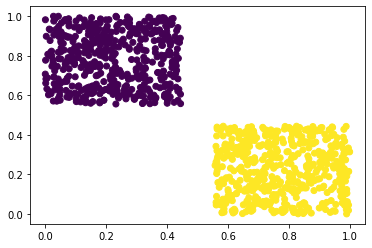

In [80]:
import matplotlib.pyplot as plt

X_plot= np.asarray(norm_x_cat_syn_numsim)
Y_plot= np.asarray(y_cat_syn)

plt.scatter(X_plot[:,0],X_plot[:,1],c=Y_plot)

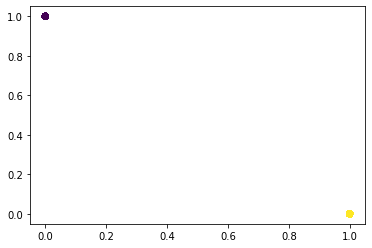

In [81]:
X_plot= np.asarray(norm_x_cat_syn)
Y_plot= np.asarray(y_cat_syn)

plt.scatter(X_plot[:,0],X_plot[:,1],c=Y_plot)

In [27]:
synth_6ft_cat= pd.concat([norm_x_cat_syn[categor_columns], norm_x_syn[norm_x_syn.columns]], axis=1)
synth_6ft_cat

,cat_core_1,cat_core_2,core_1,core_2,noise_1,noise_2
0,1.0,0.0,0.425977,0.626863,0.368465,0.345838
1,1.0,0.0,0.359321,0.603430,0.427822,0.123927
2,1.0,0.0,0.284062,0.770929,0.495906,0.455156
3,1.0,0.0,0.563072,0.663184,0.442565,0.118440
4,1.0,0.0,0.439284,0.777905,0.063690,0.362022
...,...,...,...,...,...,...
995,0.0,1.0,0.297314,0.251517,0.932540,0.240728
996,0.0,1.0,0.680541,0.727616,0.338369,0.363961
997,0.0,1.0,0.568357,0.547665,0.711681,0.636480
998,0.0,1.0,0.466742,0.492298,0.122402,0.612373


In [29]:
norm_x_cat_syn_numsim2= texp.ohe_cat_to_numerical_simulator(synth_6ft_cat, categor_columns, delta=0.2)

norm_x_cat_syn_numsim2

,cat_core_1,cat_core_2,core_1,core_2,noise_1,noise_2
0,0.871357,0.169308,0.425977,0.626863,0.368465,0.345838
1,0.918916,0.002687,0.359321,0.603430,0.427822,0.123927
2,0.886778,0.135844,0.284062,0.770929,0.495906,0.455156
3,0.870233,0.202440,0.563072,0.663184,0.442565,0.118440
4,0.835580,0.012382,0.439284,0.777905,0.063690,0.362022
...,...,...,...,...,...,...
995,0.027765,0.940751,0.297314,0.251517,0.932540,0.240728
996,0.147036,0.920715,0.680541,0.727616,0.338369,0.363961
997,0.268092,0.851790,0.568357,0.547665,0.711681,0.636480
998,0.065203,0.898606,0.466742,0.492298,0.122402,0.612373


In [32]:
cat_synth= pd.read_csv('datasets/TEXP_cat_synth_data_3.csv')

# split synth into features (x) and target (y)
x_cat_syn= cat_synth.loc[:,cat_synth.columns[0:5]]
y_cat_syn= cat_synth.loc[:,cat_synth.columns[5:6]]

numeric_columns= ['noise_1','noise_2']
categor_columns= list(filter(lambda x:x not in numeric_columns,x_cat_syn.columns))

norm_x_cat_syn3= texp.normalize_selected(x_cat_syn, numeric_columns)

norm_x_cat_syn3

,cat_core_1,cat_core_2,cat_core_3,noise_1,noise_2
0,1.0,0.0,0.0,0.374895,0.428636
1,1.0,0.0,0.0,0.683366,0.601001
2,1.0,0.0,0.0,0.070380,0.157265
3,1.0,0.0,0.0,0.070453,0.034304
4,1.0,0.0,0.0,0.776376,0.851161
...,...,...,...,...,...
995,0.0,0.0,1.0,0.550865,0.188924
996,0.0,0.0,1.0,0.693748,0.212528
997,0.0,1.0,0.0,0.690272,0.923429
998,0.0,0.0,1.0,0.941784,0.802001


In [44]:
import math

n_insts= math.ceil(norm_x_cat_syn3.shape[0]/2)

arr_x_cat_syn3= np.asarray(norm_x_cat_syn3)

cat_syn_aux1= arr_x_cat_syn3[:math.ceil(n_insts/2),:3]
cat_syn_aux2= arr_x_cat_syn3[math.ceil(n_insts/2):(math.ceil(n_insts/2)+n_insts),:3]
cat_syn_aux3= arr_x_cat_syn3[(math.ceil(n_insts/2)+n_insts):,:3]

cat_syn_aux= np.concatenate((cat_syn_aux1, cat_syn_aux3), axis=0)
cat_syn_aux= np.concatenate((cat_syn_aux, cat_syn_aux2), axis=0)

categor_columns3= ['cat_core_1','cat_core_2','cat_core_3']
cat_syn_aux= pd.DataFrame(data=cat_syn_aux, columns=categor_columns3)

norm_syn_7ft_cat_num= pd.concat([cat_syn_aux, norm_x_syn], axis=1)

norm_syn_7ft_cat_num

,cat_core_1,cat_core_2,cat_core_3,core_1,core_2,noise_1,noise_2
0,1.0,0.0,0.0,0.425977,0.626863,0.368465,0.345838
1,1.0,0.0,0.0,0.359321,0.603430,0.427822,0.123927
2,1.0,0.0,0.0,0.284062,0.770929,0.495906,0.455156
3,1.0,0.0,0.0,0.563072,0.663184,0.442565,0.118440
4,1.0,0.0,0.0,0.439284,0.777905,0.063690,0.362022
...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.297314,0.251517,0.932540,0.240728
996,0.0,1.0,0.0,0.680541,0.727616,0.338369,0.363961
997,0.0,1.0,0.0,0.568357,0.547665,0.711681,0.636480
998,0.0,1.0,0.0,0.466742,0.492298,0.122402,0.612373
